In [ ]:
import pandas as pd
data=pd.read_csv(r"Salary_Data_custom.csv")
data.head(10)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [ ]:
data.shape

(30, 2)

In [ ]:
#check for the null values:

data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:
  # Assigning independent and Dependent variables very very important:
  x=data.iloc[:, :1].values
  y=data.iloc[:, 1:2].values

  # Break Down:
  # In this particular dataset we have Years of Experience and Salary ; and the goal is to predict the salary based on the
  # Years of Experience.

  # Years of Experience(independent) -> Linear Regression -> Salary(Dependent)

  # iloc means select the data by the position.
  # iloc(:rows,:columns)

  # x=data.iloc[:, :1].values
  # The : here before comma represents take all rows from the dataset.
  # The :1 after the comma here means take columns starting from the position 0 but doesnot include the Position 1.

  # y=data.iloc[:, 1:2].values
  #   The : here before comma represents take all rows from the dataset.
  #   The 1:2 after the comma here means take columns starting from the position 1 but doesnot include the Position 2.

  # values:
  # Converts the pandas dataframes into the numpy array for processing which is the format used by the scikit learn model later.

print(x[:5])
print(y[:5])

[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]]
[[39343]
 [46205]
 [37731]
 [43525]
 [39891]]


In [ ]:
#Now splitting the dataset into Training and the testing:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#Here test_size means 20% for the testing and 80% for the training.


In [ ]:
#Fitting the linear regression model:

from sklearn.linear_model import LinearRegression

model= LinearRegression() # Creating a Linear Regression Model.
model.fit(x_train,y_train)#Giving the model training data set examples it tries to figure out a line that best fits the data points by finding y=mx+c
y_pred=model.predict(x_test)#Giving the model testing examples

In [ ]:
print(y_pred)
print(y_test)

[[115790.21011287]
 [ 71498.27809463]
 [102596.86866063]
 [ 75267.80422384]
 [ 55477.79204548]
 [ 60189.69970699]]
[[112635]
 [ 67938]
 [113812]
 [ 83088]
 [ 64445]
 [ 57189]]


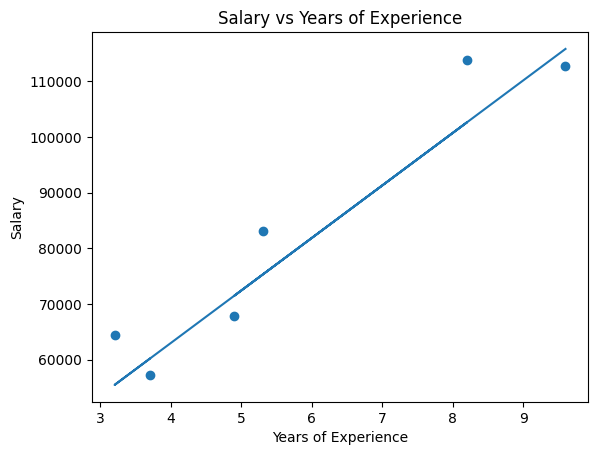

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.show()

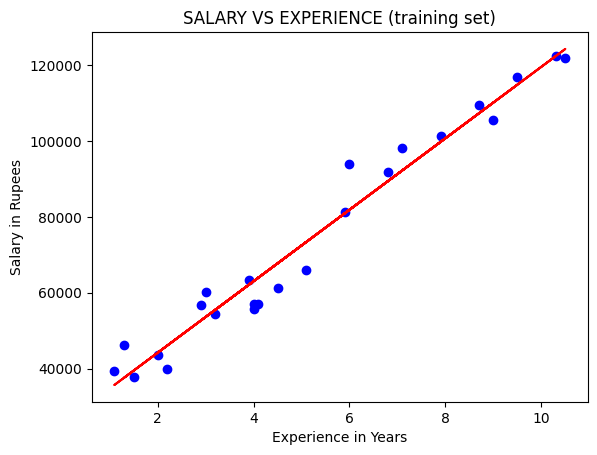

In [ ]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('SALARY VS EXPERIENCE (training set)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary in Rupees')
plt.show()

In [1]:
# EXERCISE 1
# Linear Regression to predict Taxi Fare
# Dataset: City of Chicago Taxi Trips

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

data = pd.read_csv('/content/Chicago_Taxi_Trips.csv')

print(data.head())
print(data.shape)
print(data.isnull().sum())

# Select independent and dependent variables
X = data[['Trip Miles', 'Trip Seconds']]
y = data['Fare']

# Remove missing values
df = pd.concat([X, y], axis=1).dropna()
X = df[['Trip Miles', 'Trip Seconds']]
y = df['Fare']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Predicted Fare:")
print(y_pred)

print("Actual Fare:")
print(y_test.values)

# Model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Training score
print("Training R2 Score:", model.score(X_train, y_train))

# Testing score
print("Testing R2 Score:", model.score(X_test, y_test))

FileNotFoundError: [Errno 2] No such file or directory: '/content/Chicago_Taxi_Trips.csv'

In [2]:
# EXERCISE 2
# Linear Regression to predict Body Weight
# Independent variables: Height, Age, Gender
# Dependent variable: Weight

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Create dataset from the given table
data = pd.DataFrame({
    'Weight': [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    'Height': [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    'Age': [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    'Gender': ['Male', 'Male', 'Male', 'Male', 'Male',
               'Female', 'Female', 'Female', 'Female', 'Female']
})

print(data)

print(data.shape)
print(data.isnull().sum())

# Convert Gender into numerical values
data['Gender'] = data['Gender'].map({
    'Male': 1,
    'Female': 0
})

# Independent variables
X = data[['Height', 'Age', 'Gender']]

# Dependent variable
y = data['Weight']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Predicted Weight:")
print(y_pred)

print("Actual Weight:")
print(y_test.values)

# Model parameters
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Prediction for a new person
new_person = pd.DataFrame({
    'Height': [1.75],
    'Age': [30],
    'Gender': [1]
})

predicted_weight = model.predict(new_person)

print("Predicted Weight for New Person:", predicted_weight[0])

   Weight  Height  Age  Gender
0      79    1.80   35    Male
1      69    1.68   39    Male
2      73    1.82   25    Male
3      95    1.70   60    Male
4      82    1.87   27    Male
5      55    1.55   18  Female
6      69    1.50   89  Female
7      71    1.78   42  Female
8      64    1.67   16  Female
9      69    1.64   52  Female
(10, 4)
Weight    0
Height    0
Age       0
Gender    0
dtype: int64
Predicted Weight:
[56.85651025 79.10576115]
Actual Weight:
[64 69]
Coefficients: [32.8353363   0.31729474 14.62311848]
Intercept: -3.0552172392595196
Mean Squared Error: 76.57792714844265
R2 Score: -11.252468343750825
Predicted Weight for New Person: 78.548582018849
